# One echo, then sixteen, then seventy-two

[`../se_2d/01_build.ipynb`](../se_2d/01_build.ipynb) established the rule and built a spin echo out
of it: one echo per shot, one shot per line, **four and a quarter minutes** for 128 lines. This
notebook changes the length of a list.

| | | |
|---|---|---|
| `echoes=1` | a conventional spin echo | 128 shots |
| `echoes=16` | what a vendor calls TSE or FSE | 8 shots plus a dummy, 18 s |
| `echoes=72`, one shot, `partial_fourier=0.625` | HASTE | 0.8 s, one breath hold |

They are the **same composition**. `FSE2D(echoes=1)` is asserted against what `se_2d/01` writes,
event for event, in `tests/modules/test_se_notebooks.py`.

What a train adds is not more physics, it is a **table**. `segments` is a list of line lists, one per
shot, and that one argument carries the turbo factor, the effective TE and the ordering. No
generator ships for it: `writeTSE.m`'s own reordering `circshift` is commented *"TSE echo time
magic"*, which is policy rather than arithmetic.

**And a train has one failure mode a single shot cannot have.** Shot 0 starts from thermal
equilibrium and every later shot starts from whatever the last TR recovered to. Interleaved
segmentation gives each shot a *comb* in k-space, so that difference is a periodic modulation — and
a periodic modulation of k-space is a **replica of the object**, not a blur. It is the same effect
`../mprage_2d/` found for a segmented GRE, and it is why `DUMMY_SHOTS` is not zero below.

**Output:** four `.seq` files — an FSE at three orderings, and HASTE.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

import seqcraft as sc

opts = pp.Opts(
    max_grad=32, grad_unit='mT/m',
    max_slew=130, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
)

FOV_MM = (256.0, 256.0)
MATRIX = (128, 128)
THICKNESS_MM = 5.0
REFOCUS_FACTOR = 1.25
EXCITE_DURATION_S = 2.5e-3
REFOCUS_DURATION_S = 4e-3
BANDWIDTH_HZ_PX = 200.0
CRUSH_CYCLES_SLICE = 3.0
CRUSH_CYCLES_READOUT = 0.0       # none on the readout axis; see ../se_2d/01
SPOIL_CYCLES = 4.0
SPOIL_AXIS = ('x', 'z')

ECHOES = 16
TR_S = 2.0
DUMMY_SHOTS = 1                  # shot 0 starts from equilibrium and the rest do not -- see 02

NX, NY = MATRIX
CENTER_LINE = NY // 2
DK_X, DK_Y = 1e3 / FOV_MM[0], 1e3 / FOV_MM[1]
VOXEL_MM = {'x': FOV_MM[0] / NX, 'y': FOV_MM[1] / NY, 'z': THICKNESS_MM}

SEQ_DIR = Path('seq')
SEQ_DIR.mkdir(exist_ok=True)

print(f'{NX} x {NY}, turbo {ECHOES} in {NY // ECHOES} shots plus {DUMMY_SHOTS} dummy: '
      f'{(NY // ECHOES + DUMMY_SHOTS) * TR_S:.0f} s against {NY * TR_S / 60:.1f} min for one '
      f'echo per shot')

d:\MIniconda\envs\NUM\Lib\site-packages\sigpy\config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
DLL load failed while importing cudnn: The specified module could not be found.
  warnings.warn(


128 x 128, turbo 16 in 8 shots plus 1 dummy: 18 s against 4.3 min for one echo per shot


---
## `FSE2D`

The `__init__` is `se_2d/01`'s arithmetic with nothing added: the three window minima resolved into
one crusher window, the three bounds resolved into one echo spacing, and the shift that keeps the
echo at the midpoint when a bound other than the train wins. **The only crusher is on the slice
axis** — the readout axis carries the *balance* the conjugation requires and nothing else.

What `build` adds is the loop over `segments`, `dummy_shots`, and two labels. **`LIN` per echo**,
because a readout is identical every echo and does not know which line it carries; **`SEG` per
shot**. **`ECO` is deliberately not emitted** — every echo of an FSE shot goes into *one* image at a
different `ky`, so an echo counter would tell a reconstruction to split what belongs together.

In [2]:
class FSE2D(sc.Module):
    """A 2D turbo spin echo: one excitation and `echoes` refocused readouts per shot."""

    def __init__(self, *, opts, fov_mm, matrix, thickness_mm, echoes=1, echo_spacing_s=None,
                 tr_s=None, flip_deg=90.0, refocus_flip_deg=180.0, bandwidth_hz_px=200.0,
                 partial_fourier=1.0, excitation_duration_s=2.5e-3, refocus_duration_s=4e-3,
                 refocus_thickness_factor=1.25, crush_cycles_slice=3.0,
                 crush_cycles_readout=0.0, spoil_cycles_per_voxel=4.0,
                 spoil_axis=('x', 'z'), tag=None):
        super().__init__(opts=opts, tag=tag)
        fov_x, fov_y = (fov_mm, fov_mm) if np.isscalar(fov_mm) else fov_mm
        nx, ny = int(matrix[0]), int(matrix[1])
        self.fov_mm, self.matrix = (float(fov_x), float(fov_y)), (nx, ny)
        self.thickness_mm = float(thickness_mm)
        self.echoes = int(echoes)
        raster = sc.Raster(opts.grad_raster_time)
        self._block_raster = sc.Raster(opts.block_duration_raster)

        self.exc = sc.modules.Excitation(opts=opts, flip_deg=flip_deg,
                                         thickness_mm=self.thickness_mm,
                                         duration_s=excitation_duration_s)
        # prephase=False: in a CPMG train the readout's dephasing is half of a pair that straddles
        # a refocusing pulse, so there is no event of its own to cancel it.
        self.ro = sc.modules.CartesianLine(opts=opts, fov_mm=fov_x, matrix=nx, axis='x',
                                           bandwidth_hz_px=bandwidth_hz_px,
                                           partial_fourier=partial_fourier, prephase=False)
        # The two readout-axis lobes are a *balance*, not a crusher: their mean is
        # `crush_cycles_readout` (zero) and their difference is fixed by the readout's own
        # asymmetry about the echo sample.
        self.lobe_area_per_m = crush_cycles_readout / (self.fov_mm[0] / nx / 1e3)
        self.skew_per_m = (float(self.ro.gx.area) - 2 * self.ro.area_to_echo_per_m) / 2.0

        def refocusing(window_s):
            return sc.modules.Refocusing(
                opts=opts, thickness_mm=self.thickness_mm * refocus_thickness_factor,
                flip_deg=refocus_flip_deg, duration_s=refocus_duration_s,
                crush_cycles_per_voxel=crush_cycles_slice, crush_voxel_mm=self.thickness_mm,
                crush_duration_s=window_s)

        def encode(window_s):
            return sc.modules.PhaseEncode(opts=opts, fov_mm=fov_y, matrix=ny, axis='y',
                                          duration_s=window_s)

        # One window, three axes: GRE2DTR's winder coupling with the parts renamed.
        self.crush_min_s = {
            'z': refocusing(None).min_crush_duration_s,
            'x': max(float(pp.calc_duration(pp.make_trapezoid(
                'x', area=self.lobe_area_per_m + s, system=opts)))
                for s in (self.skew_per_m, -self.skew_per_m)),
            'y': encode(None).min_duration_s,
        }
        crush_s = float(raster.ceil(max(self.crush_min_s.values())))
        if echo_spacing_s is not None:
            # Widening the window by d lengthens the echo spacing by exactly 2d: the echo moves by
            # d and time_to_crusher() - time_to_center() does not depend on the window at all.
            probe = refocusing(crush_s)
            base = 2 * (probe.time_to_crusher() - probe.time_to_center() + crush_s
                        + self.ro.time_to_echo())
            crush_s = float(raster.ceil(crush_s + max(0.0, (float(echo_spacing_s) - base) / 2.0)))

        self.crush_s = crush_s
        self.refoc, self.pe = refocusing(crush_s), encode(crush_s)
        self.lobe_in = pp.make_trapezoid('x', area=self.lobe_area_per_m + self.skew_per_m,
                                         duration=crush_s, system=opts)
        self.lobe_out = pp.make_trapezoid('x', area=self.lobe_area_per_m - self.skew_per_m,
                                          duration=crush_s, system=opts)
        self.gx_s = float(pp.calc_duration(self.ro.gx))
        self.readout_s = 2 * crush_s + self.gx_s
        self.ro_start_s = self.refoc.time_to_crusher()

        # Three minima, and the achieved spacing reports which one applied.  The last is not a
        # timing preference: below it, z is on -- and the next RF may be on -- while the ADC is
        # open, which is signal loss rather than an illegal block.
        self.dephase_area_per_m = float(self.lobe_in.area) + self.ro.area_to_echo_per_m
        dephaser_min_s = float(pp.calc_duration(pp.make_trapezoid(
            'x', area=self.dephase_area_per_m, system=opts)))
        train_s = 2 * (self.ro_start_s - self.refoc.time_to_center() + crush_s
                       + self.ro.time_to_echo())
        self.bounds_s = {
            'train': train_s,
            'first interval': 2 * ((self.exc().duration - self.exc.time_to_center())
                                   + max(0.0, dephaser_min_s - crush_s)
                                   + self.refoc.time_to_center()),
            'adc clearance': 2 * (self.ro_start_s + self.readout_s - crush_s - train_s / 2),
        }
        self.bound = max(self.bounds_s, key=self.bounds_s.get)
        half_s = float(raster.ceil(max(self.bounds_s.values()) / 2))
        self.echo_spacing_s = 2 * half_s
        # Whatever the train does not need, the echo still has to sit at the midpoint between its
        # two pulses -- the primary and stimulated pathways only coincide there.
        self.shift_s = float(raster.ceil(half_s - train_s / 2))
        self.t_refoc_s = float(raster.ceil(
            self.exc.time_to_center() + half_s - self.refoc.time_to_center()))
        # The dephaser ends where the refocusing plateau starts, so it lives inside the *leading*
        # crusher window and only its overhang costs anything.
        dephaser_s = float(raster.ceil(max(dephaser_min_s, self.t_refoc_s + crush_s
                                           - self.exc().duration)))
        self.dephaser = pp.make_trapezoid('x', area=self.dephase_area_per_m,
                                          duration=dephaser_s, system=opts)

        self.spoilers = {axis: sc.modules.spoiler(opts, cycles_per_voxel=spoil_cycles_per_voxel,
                                                  voxel_mm=self.voxel_mm(axis), axis=axis)
                         for axis in spoil_axis}
        self.shot_s = (self.t_refoc_s + (self.echoes - 1) * self.echo_spacing_s
                       + self.ro_start_s + self.shift_s + self.readout_s
                       + max(block.duration for block in self.spoilers.values()))
        self.min_tr_s = float(self._block_raster.ceil(self.shot_s))
        if tr_s is not None and float(tr_s) < self.min_tr_s - 1e-12:
            raise sc.ConfigurationError(
                f'tr_s = {float(tr_s) * 1e3:.3f} ms is shorter than the {self.min_tr_s * 1e3:.3f} '
                f'ms a {self.echoes}-echo shot occupies, so the next excitation would land '
                f'inside the train.')
        self.tr_s = float(self._block_raster.ceil(max(tr_s or 0.0, self.min_tr_s)))

    # --------------------------------------------------------------- what it knows
    @property
    def center_line(self):
        return self.pe.center_line

    def voxel_mm(self, axis):
        """The voxel dimension along `axis`: fov/matrix in plane, the slice along z."""
        return {'x': self.fov_mm[0] / self.matrix[0], 'y': self.fov_mm[1] / self.matrix[1],
                'z': self.thickness_mm}[axis]

    def time_to_echo(self, echo=0):
        """Seconds from the start of a shot to echo `echo` -- what a tree cannot know."""
        return (self.t_refoc_s + echo * self.echo_spacing_s + self.ro_start_s + self.shift_s
                + self.crush_s + self.ro.time_to_echo())

    def te_s(self, echo=0):
        """Echo time of echo `echo`: the excitation's effective centre to that echo."""
        return self.time_to_echo(echo) - self.exc.time_to_center()

    # Both of these take `segments` rather than reading `self`, mirroring `build`, because the
    # answer moves with the table -- the same reason GRE2D.time_to_center_line is a method.
    def echo_of_center_line(self, segments):
        """``(shot, echo)`` of the readout that acquires ``center_line``, or ``None``."""
        for shot, segment in enumerate(segments):
            if self.center_line in list(segment):
                return shot, list(segment).index(self.center_line)
        return None

    def te_eff_s(self, segments):
        """The effective echo time: the TE of whichever echo carries ``center_line``."""
        found = self.echo_of_center_line(segments)
        return None if found is None else self.te_s(found[1])

    def echo_bands(self, segments):
        """
        ``echo -> span`` of |ky - center_line| across shots, in lines.

        Distance from the centre of k-space rather than signed ``ky``, and the difference is the
        whole usefulness of the number: a **centric** ordering deliberately puts its last echo at
        *both* edges, which is a span of the whole matrix in signed ky and a narrow band in
        distance.  Its point spread is symmetric and it blurs; a table whose one echo index is
        scattered over a *range of distances* modulates adjacent rows differently and ghosts.
        """
        table = [list(segment) for segment in segments]
        return {echo: max(abs(s[echo] - self.center_line) for s in table)
                - min(abs(s[echo] - self.center_line) for s in table)
                for echo in range(self.echoes)}

    # ------------------------------------------------------------------- assembly
    def build(self, *, segments, dummy_shots=0, center_mm=(0.0, 0.0, 0.0)):
        """One shot per segment, stacked at TR, after `dummy_shots` that sample nothing."""
        table = self._check(segments)
        out = sc.LogicBlock()
        shots = [table[0]] * int(dummy_shots) + table
        for n, segment in enumerate(shots):
            out.add(n * self.tr_s, self._shot(segment, segment_index=max(0, n - int(dummy_shots)),
                                              acquire=n >= int(dummy_shots),
                                              center_mm=center_mm))
        return out

    def _shot(self, lines, *, segment_index, acquire, center_mm):
        """One excitation and its echo train, as a block exactly `tr_s` long."""
        x, y, z = (float(v) for v in center_mm)
        if y != 0.0:
            raise sc.ConfigurationError(
                f'center_mm y = {y:g} mm is out of scope: a phase-encode shift is a per-line ADC '
                f'phase, not a per-shot frequency.')
        # Excite about +y, refocus about +x -- 90 degrees apart is the fixed point of the map a
        # refocusing pulse applies to transverse phase, and the receiver stays at 0.
        out = sc.LogicBlock('shot').add(0.0, self.exc(phase_deg=90.0, position_mm=z))
        out.add(self.t_refoc_s + self.crush_s - float(pp.calc_duration(self.dephaser)),
                self.dephaser)
        for n, line in enumerate(lines):
            t_ref = self.t_refoc_s + n * self.echo_spacing_s
            t_ro = t_ref + self.ro_start_s + self.shift_s
            out.add(t_ref, self.refoc(phase_deg=0.0, position_mm=z))
            # The blip goes *after* the 180 and the rewinder *before the next one*, so ky is zero
            # at every refocusing centre.  Putting the blip before the pulse -- which a
            # single-echo reference legally does -- makes every later pulse flip the encode.
            out.add(t_ref + self.ro_start_s, self.pe(line=line))
            readout = sc.LogicBlock('readout').add(0.0, self.lobe_in)
            readout.add(self.crush_s, self.ro(acquire=acquire, offset_mm=x))
            readout.add(self.crush_s + self.gx_s, self.lobe_out)
            out.add(t_ro, readout)
            # Not at the echo: that instant is an ADC-raster quantity, gradient starts are not,
            # and sc.compile refuses it by name.
            out.add(t_ro + self.readout_s - self.crush_s, self.pe(line=line, rewind=True))
            if acquire:
                out.add(t_ro, pp.make_label(type='SET', label='LIN', value=int(line)))
                if n == 0:
                    out.add(t_ro, pp.make_label(type='SET', label='SEG',
                                                value=int(segment_index)))
        for block in self.spoilers.values():
            out.add(t_ro + self.readout_s, block)
        fill = float(self._block_raster.ceil(self.tr_s - self.shot_s))
        if fill > 1e-9:
            out.add(self.shot_s, pp.make_delay(fill))
        return out

    # ---------------------------------------------------------------- the refusals
    def _check(self, segments):
        """
        What the compiler cannot see about a table.

        The band check **warns** rather than refuses, because a table that scatters one echo index
        across k-space is a legitimate experiment as well as a common mistake -- and the symptom,
        ghosting along the phase-encode direction, reads as motion rather than as a table problem.
        """
        table = [[int(line) for line in segment] for segment in segments]
        if not table or not all(table):
            raise sc.ConfigurationError('segments must be a non-empty list of non-empty shots')
        wrong = [n for n, segment in enumerate(table) if len(segment) != self.echoes]
        if wrong:
            raise sc.ConfigurationError(
                f'segment(s) {wrong[:8]} do not have {self.echoes} lines, and every shot plays '
                f'{self.echoes} refocusing pulses whether or not they sample.')
        seen = [line for segment in table for line in segment]
        outside = sorted({line for line in seen if not 0 <= line < self.matrix[1]})
        if outside:
            raise sc.ConfigurationError(
                f'{len(outside)} line(s) fall outside 0 ... {self.matrix[1] - 1}: {outside[:8]}.')
        repeated = sorted({line for line in seen if seen.count(line) > 1})
        if repeated:
            raise sc.ConfigurationError(
                f'{len(repeated)} line(s) are acquired more than once: {repeated[:8]}.  Two '
                f'readouts writing one k-space address is what the compiler rejects downstream, '
                f'with less to say about it than here.')
        if self.center_line not in seen:
            warnings.warn(f'no segment acquires the centre line {self.center_line}, so the image '
                          f'has no DC term and te_eff_s is undefined.',
                          sc.SeqCraftWarning, stacklevel=3)
        wide = {echo: span for echo, span in self.echo_bands(table).items()
                if span > max(1, self.matrix[1] // self.echoes)}
        if wide:
            worst = max(wide, key=wide.get)
            warnings.warn(
                f'{len(wide)} echo index(es) fill widely separated ky: echo {worst} spans '
                f'{wide[worst]} lines of distance from the centre of k-space, against the '
                f'{max(1, self.matrix[1] // self.echoes)} a contiguous band would.  Adjacent '
                f'k-space rows then carry T2 weightings many echoes apart, and the symptom is '
                f'ghosting along the phase-encode direction that reads as motion.  Not refused: '
                f'a deliberate experiment is a legitimate thing to build.',
                sc.SeqCraftWarning, stacklevel=3)
        return table

### Turbo 1, 16 and 72, on one instance of the arithmetic

Three different sequences and one design. What has to hold at every turbo factor is the same three
things: **k exact at every echo**, the refocusing pulses **uniformly spaced**, and every echo at the
**midpoint** between its two pulses — the last two because an FSE signal is a mixture of primary and
stimulated echoes, and they only coincide there.

In [3]:
def settings(**overrides):
    """The protocol, with anything the caller wants to vary replacing its default."""
    base = dict(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM, tr_s=TR_S,
                bandwidth_hz_px=BANDWIDTH_HZ_PX, excitation_duration_s=EXCITE_DURATION_S,
                refocus_duration_s=REFOCUS_DURATION_S, refocus_thickness_factor=REFOCUS_FACTOR,
                crush_cycles_slice=CRUSH_CYCLES_SLICE, crush_cycles_readout=CRUSH_CYCLES_READOUT,
                spoil_cycles_per_voxel=SPOIL_CYCLES, spoil_axis=SPOIL_AXIS)
    return {**base, **overrides}


def interleaved(echoes=ECHOES, ny=NY):
    """Shot s takes every `shots`-th line, so each echo index owns a contiguous band of ky."""
    shots = ny // echoes
    return [[s + n * shots for n in range(echoes)] for s in range(shots)]


def measure(module, segments, dummy_shots=0):
    """Compile, then read k, the pulse spacing and the echo placement back out of the tree."""
    lines = [line for segment in segments for line in segment]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', sc.SeqCraftWarning)
        tree = module(segments=segments, dummy_shots=dummy_shots)
        seq = sc.compile(tree, opts, name='probe')
        k = sc.kspace(tree, opts)
    at_echo = k['k_adc'].reshape(3, len(lines), module.ro.num_samples)[
        :, :, module.ro.pre_echo_samples]
    want = (np.asarray(lines) - CENTER_LINE) * DK_Y
    # Per shot, because the TR gap between shots is not an echo spacing.
    centres = np.asarray(k['t_refocusing']).reshape(-1, module.echoes)
    echoes = np.asarray(k['t_adc']).reshape(len(lines), module.ro.num_samples)[
        :, module.ro.pre_echo_samples].reshape(-1, module.echoes)
    midpoints = (centres[dummy_shots:, :-1] + centres[dummy_shots:, 1:]) / 2
    return tree, seq, dict(
        worst=max(np.abs(at_echo[0]).max(), np.abs(at_echo[2]).max(),
                  np.abs(at_echo[1] - want).max()),
        spread=float(np.ptp(np.diff(centres, axis=1))) if module.echoes > 1 else 0.0,
        offset=float(np.abs(echoes[:, :-1] - midpoints).max()) if module.echoes > 1 else 0.0)


print(f'{"echoes":>7s} {"shots":>6s} {"blocks":>7s} {"scan":>7s} {"esp":>9s} {"TE1":>9s} '
      f'{"worst |k|":>10s} {"spacing":>9s} {"vs midpoint":>12s}')
for echoes in (1, 8, ECHOES, 72):
    fse = FSE2D(**settings(echoes=echoes))
    tree, seq, got = measure(fse, interleaved(echoes))
    print(f'{echoes:7d} {NY // echoes:6d} {len(seq.block_events):7d} {tree.duration:6.1f}s '
          f'{fse.echo_spacing_s * 1e3:8.3f}ms {fse.te_s() * 1e3:8.3f}ms {got["worst"]:10.2e} '
          f'{got["spread"] * 1e12:6.2f} ps {got["offset"] * 1e6:9.2f} us')

fse = FSE2D(**settings(echoes=ECHOES))
print()
print(f'window {fse.crush_s * 1e6:.0f} us from the three minima ' +
      ', '.join(f'{a} {v * 1e6:.0f} us' for a, v in fse.crush_min_s.items())
      + '  <- the slice crusher sets it, and it is the only crusher')
print('bounds ' + ', '.join(f'{k} {v * 1e3:.3f} ms' for k, v in fse.bounds_s.items())
      + f'  ({fse.bound}-bound)')
print()
print(f'The echo lands within one gradient raster ({opts.grad_raster_time * 1e6:.0f} us) of the')
print('midpoint, and not at zero: the echo instant lives on the ADC raster and the gradients that')
print('surround it live on the gradient raster.')

 echoes  shots  blocks    scan       esp       TE1  worst |k|   spacing  vs midpoint
      1    128     896  256.0s   10.700ms   10.702ms   2.02e-07   0.00 ps      0.00 us
      8     16     336   32.0s   10.700ms   10.702ms   2.02e-07   0.00 ps      1.95 us
     16      8     296   16.0s   10.700ms   10.702ms   2.02e-07   0.00 ps      1.95 us
     72      1     149    2.0s   10.700ms   10.702ms   2.02e-07   0.00 ps      1.95 us

window 700 us from the three minima z 700 us, x 40 us, y 440 us  <- the slice crusher sets it, and it is the only crusher
bounds train 10.684 ms, first interval 9.320 ms, adc clearance 10.616 ms  (train-bound)

The echo lands within one gradient raster (10 us) of the
midpoint, and not at zero: the echo instant lives on the ADC raster and the gradients that
surround it live on the gradient raster.


---
## Three orderings, written out as data

Same 128 lines, same turbo factor, same instance. What differs is which echo index acquires which
line — and therefore which T2 weighting lands where in k-space.

| | |
|---|---|
| **interleaved** | shot $s$ takes lines $s, s+8, s+16, \ldots$ — each echo index owns a contiguous band of 8 lines |
| **linear** | shot $s$ takes a contiguous block of 16 lines — each echo index is a *comb* across the whole of k-space, which is the table the band warning is about |
| **centric** | lines ordered outward from the centre and dealt round-robin, so the earliest echoes — the least T2-decayed — land nearest $k=0$, and `te_eff` is one echo spacing |

`echo_bands` measures the span of **distance from the centre of k-space**, not of signed $k_y$, for
the reason its docstring gives: centric would otherwise be flagged for a point spread that is
symmetric, and a warning a reader learns to ignore is worse than none.

In [4]:
def linear(echoes=ECHOES, ny=NY):
    return [list(range(s * echoes, (s + 1) * echoes)) for s in range(ny // echoes)]


def centric(echoes=ECHOES, ny=NY):
    order = sorted(range(ny), key=lambda line: (abs(line - ny // 2), line))
    shots = ny // echoes
    return [[order[n * shots + s] for n in range(echoes)] for s in range(shots)]


tables = {'interleaved': interleaved(), 'linear': linear(), 'centric': centric()}

print(f'{"ordering":12s} {"shot, echo of k=0":>18s} {"te_eff":>9s} {"widest echo band":>18s}')
for name, segments in tables.items():
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always', sc.SeqCraftWarning)
        fse(segments=segments)
    bands = fse.echo_bands(segments)
    widest = max(bands, key=bands.get)
    print(f'{name:12s} {str(fse.echo_of_center_line(segments)):>18s} '
          f'{fse.te_eff_s(segments) * 1e3:8.3f}ms '
          f'{f"echo {widest}: {bands[widest]:3d} lines":>18s}'
          + ('   <- warned' if caught else ''))

ordering      shot, echo of k=0    te_eff   widest echo band
interleaved              (0, 8)   96.302ms  echo 0:   7 lines
linear                   (4, 0)   10.702ms  echo 0:  64 lines   <- warned
centric                  (0, 0)   10.702ms  echo 0:   4 lines


Text(0.5, 1.02, 'which echo acquires which line -- the same 128 lines, three tables')

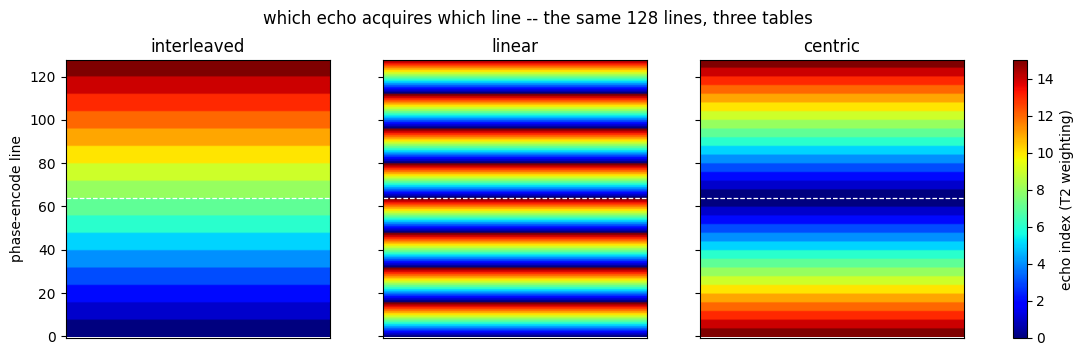

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12.6, 3.6), sharey=True)
for ax, (name, segments) in zip(axes, tables.items()):
    grid = np.full(NY, np.nan)
    for segment in segments:
        for echo, line in enumerate(segment):
            grid[line] = echo
    im = ax.imshow(grid.reshape(NY, 1), aspect='auto', cmap='jet', origin='lower',
                   extent=(0, 1, -0.5, NY - 0.5), vmin=0, vmax=ECHOES - 1)
    ax.set(title=name, xticks=[])
    ax.axhline(CENTER_LINE, color='w', lw=0.9, ls='--')
axes[0].set_ylabel('phase-encode line')
fig.colorbar(im, ax=axes, fraction=0.03, label='echo index (T2 weighting)')
fig.suptitle('which echo acquires which line -- the same 128 lines, three tables', y=1.02)

The `linear` column is the warning made visible: each echo index is a *comb* of $k_y$ with period
16, so adjacent k-space rows carry T2 weightings sixteen echoes apart. A periodic modulation of
k-space is a **replica** of the object, not a blur. `interleaved` and `centric` both keep one echo
index in a contiguous band, which is a smooth filter across $k_y$ and therefore a blur.
[`02`](02_simulate_and_reconstruct.ipynb) measures both.

### The refusals, each shown once

In [6]:
def refused(what, call):
    try:
        call()
    except sc.ConfigurationError as error:
        print(f'{what}\n  {str(error).splitlines()[0]}\n')
    else:
        raise AssertionError(f'{what} was not refused')


refused('no segments at all', lambda: fse(segments=[]))
refused('a segment that is not `echoes` long', lambda: fse(segments=[list(range(ECHOES - 1))]))
refused('a line outside the matrix', lambda: fse(segments=[[*range(ECHOES - 1), NY]]))
refused('a line acquired twice',
        lambda: fse(segments=[list(range(ECHOES)), list(range(ECHOES))]))
refused('a TR shorter than the train', lambda: FSE2D(**settings(echoes=72, tr_s=0.5)))

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always', sc.SeqCraftWarning)
    fse(segments=tables['linear'])                                   # scattered echo bands
    fse(segments=[s for s in interleaved() if CENTER_LINE not in s])  # and no centre line
print('warned rather than refused:')
for warning in caught:
    print(f'  {str(warning.message)[:150]}')

no segments at all
  segments must be a non-empty list of non-empty shots

a segment that is not `echoes` long
  segment(s) [0] do not have 16 lines, and every shot plays 16 refocusing pulses whether or not they sample.

a line outside the matrix
  1 line(s) fall outside 0 ... 127: [128].

a line acquired twice
  16 line(s) are acquired more than once: [0, 1, 2, 3, 4, 5, 6, 7].  Two readouts writing one k-space address is what the compiler rejects downstream, with less to say about it than here.

a TR shorter than the train
  tr_s = 500.000 ms is shorter than the 776.680 ms a 72-echo shot occupies, so the next excitation would land inside the train.

warned rather than refused:
  16 echo index(es) fill widely separated ky: echo 0 spans 64 lines of distance from the centre of k-space, against the 8 a contiguous band would.  Adja
  no segment acquires the centre line 64, so the image has no DC term and te_eff_s is undefined.


---
## HASTE — one shot, 72 echoes

`partial_fourier=0.625` samples 80 of 128 samples along the readout, and the train starts 8 lines
below the centre of k-space so that 72 echoes cover lines 56 … 127; the missing 56 rows come from
the conjugate symmetry of the object. **0.625 rather than 0.6** because `adc_samples_divisor`
requires the sample count to be a multiple of 4, and 0.6 of 128 is 77.

One shot means **no dummy shots and no shot-to-shot ghost** — there is nothing for a shot to be
inconsistent with. What it pays instead is the train: the last line is acquired 72 echo spacings
after the excitation, which is a point-spread function across the phase-encode direction rather than
noise. That is why HASTE is a breath-hold sequence and not a general-purpose one, and
[`02`](02_simulate_and_reconstruct.ipynb) measures its width.

In [7]:
HASTE_ECHOES, PARTIAL_FOURIER = 72, 0.625

haste = FSE2D(**settings(echoes=HASTE_ECHOES, partial_fourier=PARTIAL_FOURIER))
haste_segments = [[CENTER_LINE - 8 + n for n in range(HASTE_ECHOES)]]
tree, seq, got = measure(haste, haste_segments)

print(f'{haste.ro.num_samples} of {NX} samples, {haste.ro.pre_echo_samples} before the echo; '
      f'lines {haste_segments[0][0]} ... {haste_segments[0][-1]} of {NY}, one shot')
print(f'{len(seq.block_events)} blocks, shot {haste.shot_s * 1e3:.1f} ms, '
      f'esp {haste.echo_spacing_s * 1e3:.3f} ms ({haste.bound}-bound)')
print(f'te_eff {haste.te_eff_s(haste_segments) * 1e3:.1f} ms at echo '
      f'{haste.echo_of_center_line(haste_segments)[1]}, last echo '
      f'{haste.te_s(HASTE_ECHOES - 1) * 1e3:.0f} ms after the excitation')
print(f'worst |k| {got["worst"]:.2e} 1/m   echo vs midpoint {got["offset"] * 1e6:.2f} us')
print()
print(f'The shift that keeps the echo at the midpoint is {haste.shift_s * 1e6:.0f} us here, '
      f'because the {haste.bound} bound wins;')
print('without it the echo drifts 1.23 ms off the midpoint and every stimulated pathway with it.')

80 of 128 samples, 16 before the echo; lines 56 ... 127 of 128, one shot
293 blocks, shot 770.9 ms, esp 10.620 ms (adc clearance-bound)
te_eff 95.6 ms at echo 8, last echo 765 ms after the excitation
worst |k| 5.97e-08 1/m   echo vs midpoint 5.15 us

The shift that keeps the echo at the midpoint is 1850 us here, because the adc clearance bound wins;
without it the echo drifts 1.23 ms off the midpoint and every stimulated pathway with it.


---
## The four files

Each carries the definitions a reconstruction reads back, and the nominal k-space and the tables go
beside them so [`02`](02_simulate_and_reconstruct.ipynb) can check the parsed trajectory and the
labels against what was intended. **The three multi-shot files carry `DUMMY_SHOTS`**; HASTE does
not, because a single shot cannot be inconsistent with anything.

In [8]:
builds = {
    'fse_interleaved': (fse, tables['interleaved'], DUMMY_SHOTS),
    'fse_linear': (fse, tables['linear'], DUMMY_SHOTS),
    'fse_centric': (fse, tables['centric'], DUMMY_SHOTS),
    'haste': (haste, haste_segments, 0),
}

nominal, meta = {}, {}
for name, (module, segments, dummies) in builds.items():
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', sc.SeqCraftWarning)
        tree = module(segments=segments, dummy_shots=dummies)
        seq = sc.compile(tree, opts, name=name, definitions={
            'FOV': [FOV_MM[0] / 1e3, FOV_MM[1] / 1e3, THICKNESS_MM / 1e3],
            'SliceThickness': THICKNESS_MM / 1e3,
            'kSpaceCenterLine': CENTER_LINE,
            'TE': module.te_eff_s(segments),
            'TR': module.tr_s,
            'EchoSpacing': module.echo_spacing_s,
            'TurboFactor': module.echoes,
            'ReceiverBandwidth': BANDWIDTH_HZ_PX,
        })
        seq.write(str(SEQ_DIR / f'{name}.seq'))
        lines = [line for segment in segments for line in segment]
        nominal[name] = sc.kspace(tree, opts)['k_adc'].reshape(3, len(lines),
                                                               module.ro.num_samples)
    meta[name] = dict(echoes=module.echoes, shots=len(segments), dummy_shots=dummies,
                      te_eff_s=module.te_eff_s(segments),
                      echo_spacing_s=module.echo_spacing_s,
                      partial_fourier=module.ro.partial_fourier,
                      num_samples=module.ro.num_samples,
                      pre_echo_samples=module.ro.pre_echo_samples)
    print(f'{name:16s} {module.echoes:3d} echoes x {len(segments):3d} shots + {dummies} dummy  '
          f'{len(seq.block_events):5d} blocks  {seq.duration()[0]:6.2f} s  '
          f'te_eff {meta[name]["te_eff_s"] * 1e3:7.3f} ms  -> seq/{name}.seq')

np.savez(
    SEQ_DIR / 'fse_2d_nominal.npz',
    matrix=np.array(MATRIX), fov_mm=np.array(FOV_MM), thickness_mm=THICKNESS_MM,
    center_line=CENTER_LINE, tr_s=TR_S, bandwidth_hz_px=BANDWIDTH_HZ_PX,
    excite_duration_s=EXCITE_DURATION_S, refocus_duration_s=REFOCUS_DURATION_S,
    refocus_factor=REFOCUS_FACTOR, crush_cycles_slice=CRUSH_CYCLES_SLICE,
    crush_cycles_readout=CRUSH_CYCLES_READOUT, spoil_cycles=SPOIL_CYCLES,
    names=np.array(list(builds)),
    **{f'segments_{name}': np.array([list(s) for s in segments])
       for name, (_, segments, _) in builds.items()},
    **{f'k_{name}': value for name, value in nominal.items()},
    **{f'{key}_{name}': value for name, row in meta.items() for key, value in row.items()},
)
print(f'-> {SEQ_DIR / "fse_2d_nominal.npz"}')

fse_interleaved   16 echoes x   8 shots + 1 dummy    333 blocks   18.00 s  te_eff  96.302 ms  -> seq/fse_interleaved.seq
fse_linear        16 echoes x   8 shots + 1 dummy    333 blocks   18.00 s  te_eff  10.702 ms  -> seq/fse_linear.seq
fse_centric       16 echoes x   8 shots + 1 dummy    333 blocks   18.00 s  te_eff  10.702 ms  -> seq/fse_centric.seq
haste             72 echoes x   1 shots + 0 dummy    293 blocks    2.00 s  te_eff  95.585 ms  -> seq/haste.seq
-> seq\fse_2d_nominal.npz


---
## What this notebook established

| | |
|---|---|
| a spin echo and a turbo spin echo are **one composition** | `echoes` is the length of a list, and `FSE2D(echoes=1)` is pinned against `se_2d/01` event for event |
| the refocusing pulses are **uniformly spaced** to 0 ps and every echo is within **one gradient raster** of its midpoint | which is what makes the primary and stimulated pathways coincide, and neither is automatic |
| `segments` is **data**, and every cost of a train is a property of it | `te_eff_s` and `echo_of_center_line` therefore *take* the table rather than reading `self` |
| **shot 0 starts from equilibrium and the rest do not** | with interleaved segmentation that one difference is a comb in k-space, and a comb is a replica of the object. `DUMMY_SHOTS` is the fix, and `02` reads the comb off $k_y$ to confirm it |
| a table that scatters one echo index across `ky` **warns rather than raises** | it is the same mechanism at a different period, and a deliberate experiment is a legitimate thing to build |
| 128 lines in **18 s** instead of 4.3 minutes | at 72 echoes, in **0.8 s** |

Next: [`02_simulate_and_reconstruct.ipynb`](02_simulate_and_reconstruct.ipynb) measures what the
train costs — the point-spread width per ordering, the ghost the table makes, and the echo envelope
an imperfect refocusing angle produces.